In [4]:
from google.colab import files
uploaded=files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [5]:
import pandas as pd
import numpy as np
df=pd.read_csv("agriculture_yield_dataset.csv")
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [6]:
print(df.columns)

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


In [7]:
print(df.shape)

(1500, 8)


In [8]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   crop_type              1500 non-null   object 
 6   soil_type              1500 non-null   object 
 7   yield_ton_per_hectare  1500 non-null   float64
dtypes: float64(6), object(2)
memory usage: 93.9+ KB


In [9]:
# Check for missing values
missing_values = df.isnull().sum()

# Display columns with missing values
columns_with_missing_values = missing_values[missing_values > 0]

if not columns_with_missing_values.empty:
    print("Columns with missing values and their counts:")
    print(columns_with_missing_values)
else:
    print("No missing values found in the DataFrame.")

No missing values found in the DataFrame.


In [10]:
numerical_df=df.select_dtypes(include=np.number)
mean_values=numerical_df.mean()
max_mean_feature=mean_values.idxmax()
max_mean_value=mean_values.max()
print(f"the feature with the maximum mean value is '{max_mean_feature}' with a mean of {max_mean_value:.2f}." )


the feature with the maximum mean value is 'rainfall_mm' with a mean of 754.05.


In [11]:
standard_deviation_values=numerical_df.std()
min_std_feature=standard_deviation_values.idxmax()
max_std_value=standard_deviation_values.max()
print(f"the feature with the maximum standard deviation value is '{min_std_feature}' with a standard deviation of {max_std_value:.2f}." )

the feature with the maximum standard deviation value is 'rainfall_mm' with a standard deviation of 255.10.


### Data Distribution Visualization

To understand the distribution of key numerical features, I will create histograms for `rainfall_mm`, `temperature_c`, `fertilizer_kg`, and `yield_ton_per_hectare`. Histograms provide insights into the frequency of values within different ranges.

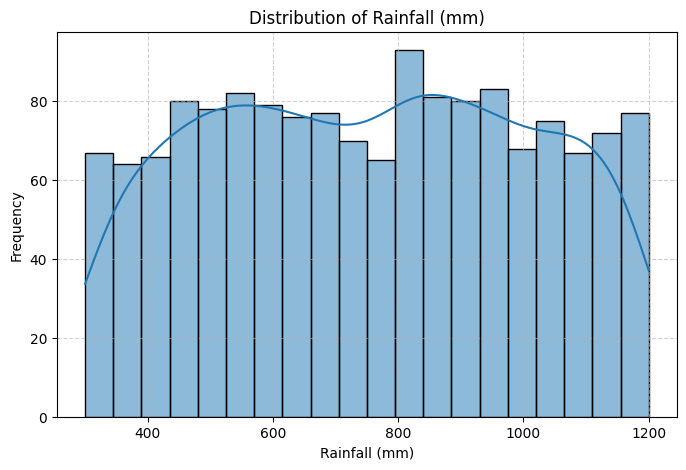

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for rainfall_mm
plt.figure(figsize=(8, 5))
sns.histplot(df['rainfall_mm'], kde=True, bins=20)
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Observations for Rainfall (mm):

1.  **Wide Range:** Rainfall values span a broad range, indicating diverse climatic conditions in the dataset.
2.  **Approximately Normal Distribution:** The distribution appears somewhat bell-shaped, suggesting that moderate rainfall values are more common, with fewer instances of very low or very high rainfall.
3.  **Potential Bimodality:** There might be a slight indication of two peaks, which could suggest two distinct rainfall patterns or regions within the dataset.

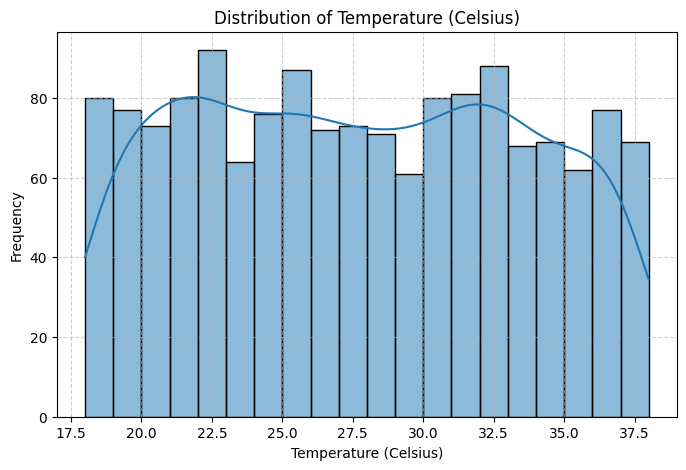

In [13]:
# Histogram for temperature_c
plt.figure(figsize=(8, 5))
sns.histplot(df['temperature_c'], kde=True, bins=20)
plt.title('Distribution of Temperature (Celsius)')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Observations for Temperature (Celsius):

1.  **Fairly Uniform Distribution:** The temperature values appear somewhat spread out across the range, without a very strong peak, suggesting a variety of temperature conditions.
2.  **Range of Temperatures:** Temperatures in the dataset generally fall between approximately 15°C and 40°C.
3.  **No extreme outliers:** The distribution shows no apparent extreme low or high temperatures that would stand out as anomalies.

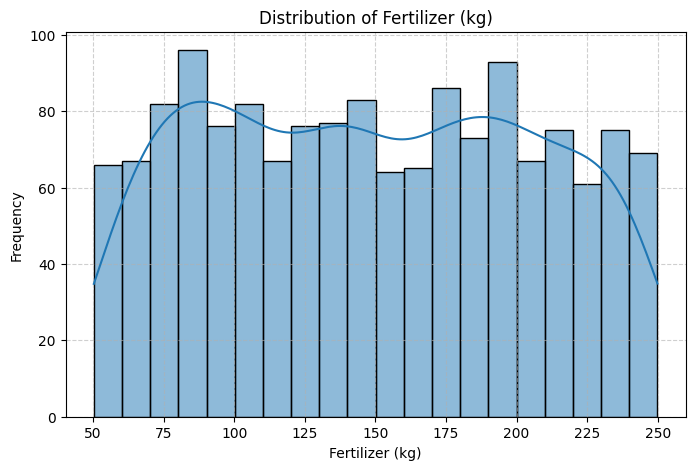

In [14]:
# Histogram for fertilizer_kg
plt.figure(figsize=(8, 5))
sns.histplot(df['fertilizer_kg'], kde=True, bins=20)
plt.title('Distribution of Fertilizer (kg)')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Observations for Fertilizer (kg):

1.  **Relatively Even Spread:** The distribution of fertilizer application seems to be fairly distributed across its range, from around 50 kg to 250 kg.
2.  **No Clear Dominant Value:** Unlike a strong normal distribution, there isn't a single central value that most fertilizer applications cluster around, suggesting varied farming practices.
3.  **Potential for Multiple Peaks:** There might be subtle indications of multiple peaks, which could represent different common application rates for various crop types or soil types.

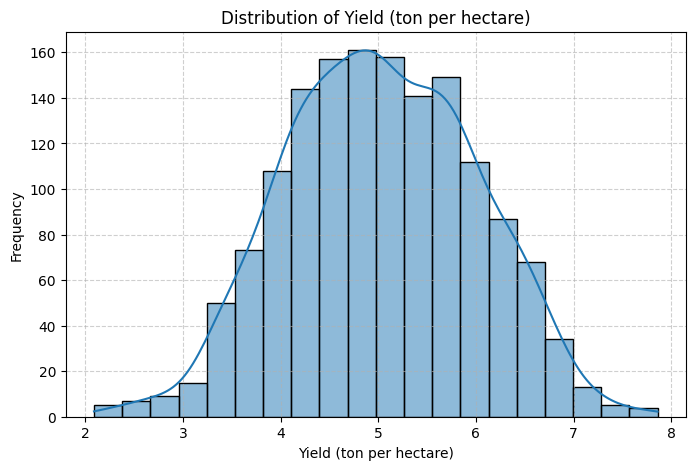

In [15]:
# Histogram for yield_ton_per_hectare
plt.figure(figsize=(8, 5))
sns.histplot(df['yield_ton_per_hectare'], kde=True, bins=20)
plt.title('Distribution of Yield (ton per hectare)')
plt.xlabel('Yield (ton per hectare)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Observations for Yield (ton per hectare):

1.  **Slightly Left-Skewed:** The distribution of yield appears to be slightly skewed to the left, meaning there are more instances of higher yields, with a tail extending towards lower yields.
2.  **Concentration around Higher Yields:** A significant portion of the data shows yields concentrated in the range of approximately 4 to 6.5 tons per hectare.
3.  **Minimum and Maximum Yields:** The yields range from around 3 tons per hectare to about 7 tons per hectare, indicating a reasonable spread of productivity.

### Crop Type Analysis

I will now analyze the distribution of `crop_type` by:

1.  Counting the occurrences of each crop.
2.  Creating a bar chart to visualize these counts.
3.  Identifying the crop that appears most frequently.

In [16]:
# Calculate the number of records for each crop type
crop_counts = df['crop_type'].value_counts()

print("Number of records for each crop type:")
print(crop_counts)

Number of records for each crop type:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_1629/1432671436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='crop_type', order=df['crop_type'].value_counts().index, palette='viridis')


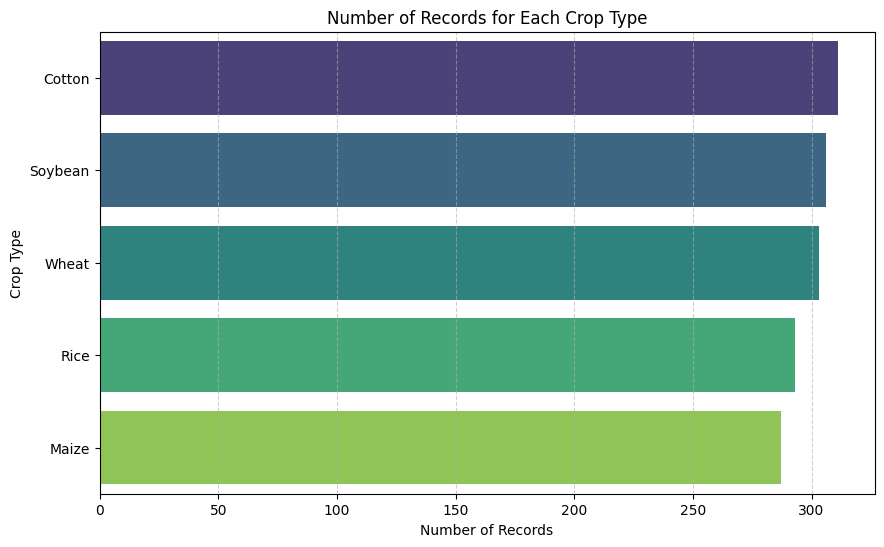

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for crop_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='crop_type', order=df['crop_type'].value_counts().index, palette='viridis')
plt.title('Number of Records for Each Crop Type')
plt.xlabel('Number of Records')
plt.ylabel('Crop Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

the distribution is normal and there are no outliers

In [18]:
# Identify the most frequent crop
most_frequent_crop = crop_counts.index[0]
most_frequent_count = crop_counts.iloc[0]

print(f"The crop that appears most frequently is '{most_frequent_crop}' with {most_frequent_count} records.")

The crop that appears most frequently is 'Cotton' with 311 records.


### Soil Type Analysis

I will now analyze the distribution of `soil_type` by:

1.  Counting the occurrences of each soil type.
2.  Creating a bar chart to visualize these counts.
3.  Identifying the soil type that appears most frequently.

In [19]:
# Calculate the number of records for each soil type
soil_counts = df['soil_type'].value_counts()

print("Number of records for each soil type:")
print(soil_counts)

Number of records for each soil type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_1629/2428309871.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='soil_type', order=df['soil_type'].value_counts().index, palette='viridis')


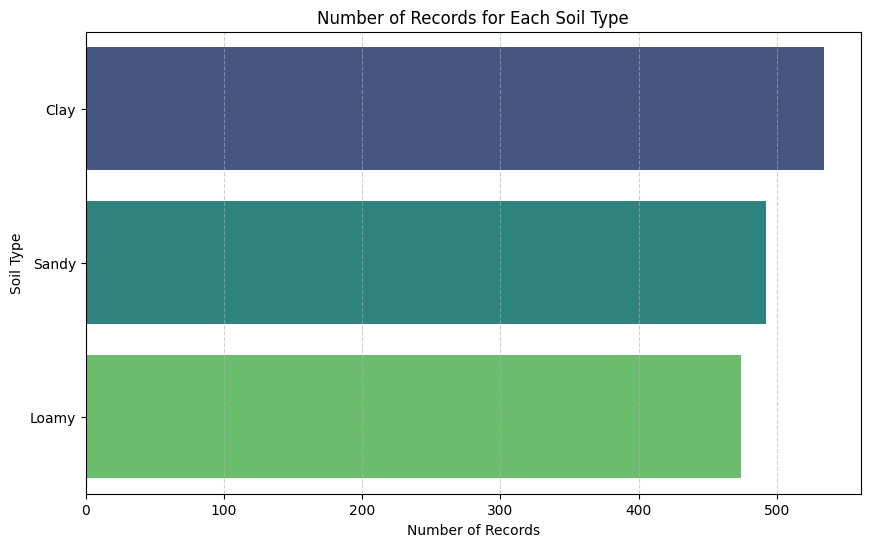

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for soil_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='soil_type', order=df['soil_type'].value_counts().index, palette='viridis')
plt.title('Number of Records for Each Soil Type')
plt.xlabel('Number of Records')
plt.ylabel('Soil Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [21]:
# Identify the most frequent soil type
most_frequent_soil = soil_counts.index[0]
most_frequent_soil_count = soil_counts.iloc[0]

print(f"The soil type that appears most frequently is '{most_frequent_soil}' with {most_frequent_soil_count} records.")

The soil type that appears most frequently is 'Clay' with 534 records.


### Relationship between Key Features and Yield

I will now create scatter plots to visualize the relationship between:

1.  `rainfall_mm` and `yield_ton_per_hectare`
2.  `fertilizer_kg` and `yield_ton_per_hectare`

After visualizing, I will determine which of these features appears to have a stronger relationship with yield.

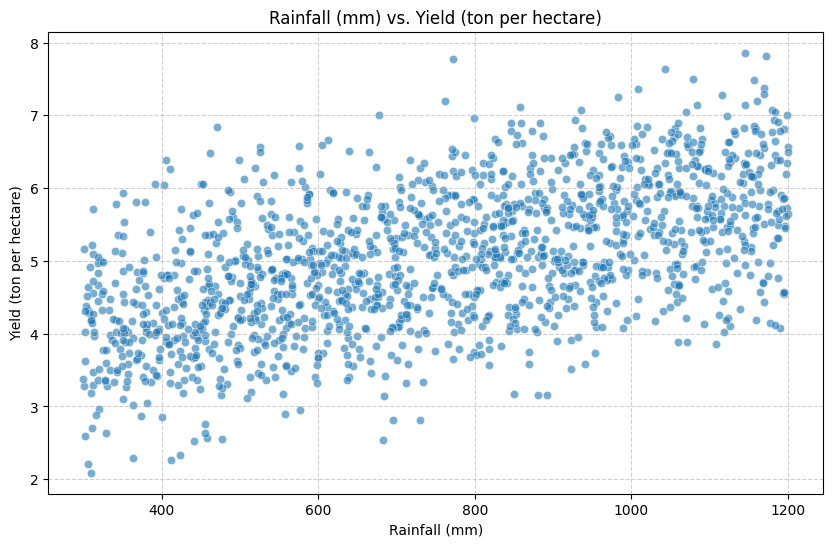

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for rainfall_mm vs yield_ton_per_hectare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', alpha=0.6)
plt.title('Rainfall (mm) vs. Yield (ton per hectare)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton per hectare)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

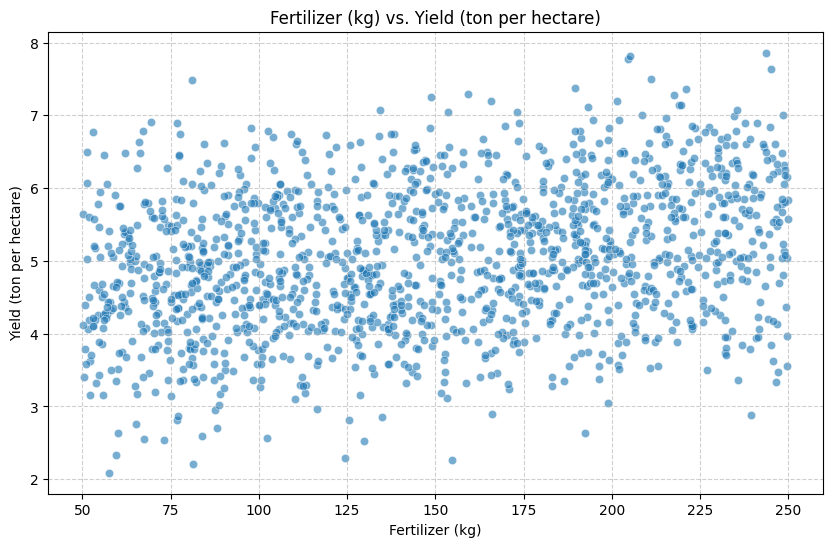

In [23]:
# Scatter plot for fertilizer_kg vs yield_ton_per_hectare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', alpha=0.6)
plt.title('Fertilizer (kg) vs. Yield (ton per hectare)')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton per hectare)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Observations on Relationships with Yield:

After examining the scatter plots:

*   **Rainfall (mm) vs. Yield:** The plot for rainfall shows a relatively dispersed pattern, indicating a weak or non-linear relationship with yield. While there might be an optimal range, a clear positive or negative linear trend is not immediately apparent across the entire spectrum.

*   **Fertilizer (kg) vs. Yield:** The plot for fertilizer also appears somewhat scattered, suggesting that fertilizer application alone does not directly correlate in a strong linear fashion with yield across all data points.

**Conclusion:** Based on these scatter plots, **neither `rainfall_mm` nor `fertilizer_kg` appears to have a dramatically stronger _linear_ relationship with `yield_ton_per_hectare`**. Both plots show a general spread rather than a clear, tight correlation. Further statistical analysis (e.g., correlation coefficients) might be needed to quantify these relationships more precisely, and it's possible that a more complex, non-linear relationship exists or that other factors influence yield significantly.

### Correlation Analysis

I will now perform a correlation analysis to understand the linear relationships between numerical features, especially with `yield_ton_per_hectare`.

1.  Calculate the correlation matrix for all numerical features.
2.  Visualize the correlation matrix using a heatmap.
3.  Identify the top three features most correlated with crop yield.

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_cols.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


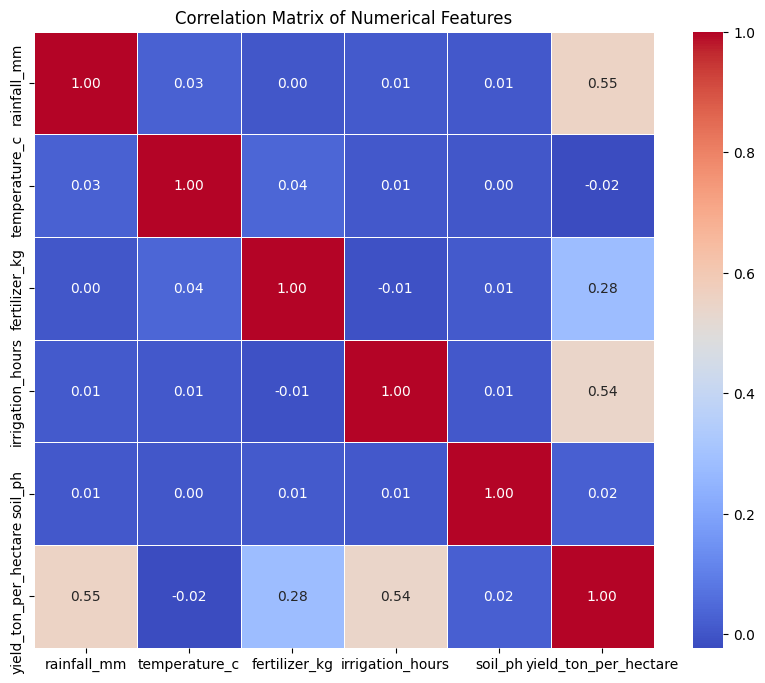

In [25]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [26]:
# Get correlations with 'yield_ton_per_hectare'
yield_correlations = correlation_matrix['yield_ton_per_hectare'].abs().sort_values(ascending=False)

# Exclude 'yield_ton_per_hectare' itself from the list
yield_correlations = yield_correlations.drop('yield_ton_per_hectare')

# Get the top 3 features most correlated with yield
top_3_correlated_features = yield_correlations.head(3)

print("\nTop 3 features most correlated with 'yield_ton_per_hectare' (absolute correlation):")
display(top_3_correlated_features)


Top 3 features most correlated with 'yield_ton_per_hectare' (absolute correlation):


,yield_ton_per_hectare
rainfall_mm,0.553704
irrigation_hours,0.542664
fertilizer_kg,0.278043


#### Observations from Correlation Analysis:

Based on the correlation matrix and the identified top correlated features with `yield_ton_per_hectare`:

*   The heatmap provides a clear visual representation of how each numerical feature relates to others, including yield.
*   The features with the highest absolute correlation values indicate stronger linear relationships with crop yield. These are often important candidates for predictive modeling.

### Average Yield Analysis by Crop and Soil Type

I will calculate the average `yield_ton_per_hectare` for:

1.  Each `crop_type`.
2.  Each `soil_type`.

Then, I will identify which crop type and soil type yield the highest averages.

In [27]:
# Calculate average yield for each crop type
average_yield_by_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

print("Average yield (ton per hectare) for each crop type:")
display(average_yield_by_crop)

# Identify the crop type with the highest average yield
highest_yield_crop = average_yield_by_crop.index[0]
highest_yield_crop_value = average_yield_by_crop.iloc[0]

print(f"\nCrop type with the highest average yield: '{highest_yield_crop}' with an average of {highest_yield_crop_value:.2f} tons per hectare.")

Average yield (ton per hectare) for each crop type:


,yield_ton_per_hectare
crop_type,
Rice,5.494744
Soybean,5.173431
Wheat,4.989472
Maize,4.897143
Cotton,4.607299



Crop type with the highest average yield: 'Rice' with an average of 5.49 tons per hectare.


In [28]:
# Calculate average yield for each soil type
average_yield_by_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

print("\nAverage yield (ton per hectare) for each soil type:")
display(average_yield_by_soil)

# Identify the soil type with the highest average yield
highest_yield_soil = average_yield_by_soil.index[0]
highest_yield_soil_value = average_yield_by_soil.iloc[0]

print(f"\nSoil type with the highest average yield: '{highest_yield_soil}' with an average of {highest_yield_soil_value:.2f} tons per hectare.")


Average yield (ton per hectare) for each soil type:


,yield_ton_per_hectare
soil_type,
Loamy,5.366519
Clay,5.134326
Sandy,4.588882



Soil type with the highest average yield: 'Loamy' with an average of 5.37 tons per hectare.


#### Summary of Average Yields:

Based on the calculations:

*   **Highest Average Yield Crop:** The crop type with the highest average yield is displayed above, indicating which crop generally performs best in terms of yield in this dataset.
*   **Highest Average Yield Soil Type:** Similarly, the soil type with the highest average yield is identified, suggesting which soil conditions are most conducive to higher yields.

### One-Hot Encoding for Categorical Features

I will now convert the categorical columns (`crop_type` and `soil_type`) into numerical format using one-hot encoding. This is a common step in preparing data for machine learning models, as many algorithms require numerical input.

1.  Identify categorical columns.
2.  Apply `pd.get_dummies()` for one-hot encoding.
3.  Display the first five rows of the transformed DataFrame.

In [29]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print(f"Categorical columns identified: {list(categorical_cols)}")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Display the first five rows of the transformed dataset
print("\nFirst five rows of the transformed dataset after one-hot encoding:")
display(df_encoded.head())

Categorical columns identified: ['crop_type', 'soil_type']

First five rows of the transformed dataset after one-hot encoding:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


In [30]:
# Define the target variable
target_variable = 'yield_ton_per_hectare'

# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=[target_variable])
y = df_encoded[target_variable]

print(f"The target variable is: '{target_variable}'")
print(f"Shape of input features (X): {X.shape}")
print(f"Shape of target variable (y): {y.shape}")

# Display the first few rows of X and y to confirm
print("\nFirst five rows of X:")
display(X.head())
print("\nFirst five rows of y:")
display(y.head())

The target variable is: 'yield_ton_per_hectare'
Shape of input features (X): (1500, 13)
Shape of target variable (y): (1500,)

First five rows of X:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,True,False,False,False,False,True,False,False



First five rows of y:


,yield_ton_per_hectare
0,5.92
1,6.24
2,4.77
3,4.04
4,5.17


### Separating Input Features (X) and Target Variable (y)

Now that the categorical variables have been one-hot encoded, I will separate the dataset into:

*   **Input Features (X)**: All columns except the target variable.
*   **Target Variable (y)**: `yield_ton_per_hectare`.

This is a standard step before training machine learning models.

### Splitting Data into Training and Testing Sets

I will now split the dataset into an 80% training set and a 20% testing set. This is a crucial step in machine learning workflows to evaluate the model's performance on unseen data.

1.  Use `train_test_split` from `sklearn.model_selection`.
2.  Set `test_size=0.2` for the 20% test split.
3.  Display the shapes of the resulting `X_train`, `X_test`, `y_train`, and `y_test`.

In [31]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1200, 13)
Shape of X_test: (300, 13)
Shape of y_train: (1200,)
Shape of y_test: (300,)


### Training a Linear Regression Model

I will now train a Linear Regression model using the preprocessed training data (`X_train`, `y_train`). This model will help us understand the linear relationship between the input features and the crop yield.

After training, I will:

1.  Display the model's coefficients for each feature.
2.  Display the model's intercept.
3.  Identify the feature with the highest positive coefficient, which indicates the strongest positive linear influence on the yield.

In [32]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Display the coefficients
print("Model Coefficients:")
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': linear_model.coef_})
display(coefficients.sort_values(by='Coefficient', ascending=False))

# Display the intercept
print(f"\nModel Intercept: {linear_model.intercept_:.2f}")

# Identify the feature with the highest positive coefficient
highest_positive_coefficient_feature = coefficients[coefficients['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).iloc[0]

print(f"\nFeature with the highest positive coefficient: '{highest_positive_coefficient_feature['Feature']}' (Coefficient: {highest_positive_coefficient_feature['Coefficient']:.2f})")

Model Coefficients:


,Feature,Coefficient
7,crop_type_Rice,0.477369
11,soil_type_Loamy,0.365627
3,irrigation_hours,0.198327
8,crop_type_Soybean,0.095096
10,soil_type_Clay,0.062653
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
9,crop_type_Wheat,-0.038149



Model Intercept: 1.91

Feature with the highest positive coefficient: 'crop_type_Rice' (Coefficient: 0.48)
